In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data import random_split
from torch import nn
from tqdm import tqdm 
from PIL import Image

In [2]:
base_dir = "../leaves_data/"
train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

In [3]:
# 统计每个类别的数量
label_counts = train_df['label'].value_counts()
unique_labels = train_df["label"].unique()
# 创建label→idx的映射
label_idx = {label: idx for idx, label in enumerate(unique_labels)}
label_idx

{'maclura_pomifera': 0,
 'ulmus_rubra': 1,
 'broussonettia_papyrifera': 2,
 'prunus_virginiana': 3,
 'acer_rubrum': 4,
 'cryptomeria_japonica': 5,
 'staphylea_trifolia': 6,
 'asimina_triloba': 7,
 'diospyros_virginiana': 8,
 'tilia_cordata': 9,
 'ulmus_pumila': 10,
 'quercus_muehlenbergii': 11,
 'juglans_cinerea': 12,
 'cercis_canadensis': 13,
 'ptelea_trifoliata': 14,
 'acer_palmatum': 15,
 'catalpa_speciosa': 16,
 'abies_concolor': 17,
 'eucommia_ulmoides': 18,
 'quercus_montana': 19,
 'koelreuteria_paniculata': 20,
 'liriodendron_tulipifera': 21,
 'styrax_japonica': 22,
 'malus_pumila': 23,
 'prunus_sargentii': 24,
 'cornus_mas': 25,
 'magnolia_virginiana': 26,
 'ostrya_virginiana': 27,
 'magnolia_acuminata': 28,
 'ilex_opaca': 29,
 'acer_negundo': 30,
 'fraxinus_nigra': 31,
 'pyrus_calleryana': 32,
 'picea_abies': 33,
 'chionanthus_virginicus': 34,
 'carpinus_caroliniana': 35,
 'zelkova_serrata': 36,
 'aesculus_pavi': 37,
 'taxodium_distichum': 38,
 'carya_tomentosa': 39,
 'picea_p

In [4]:
# 创建反向映射idx→label便于后续做预测
idx_label = {v: k for k, v in label_idx.items()}

In [5]:
class LeaveDataset(Dataset):
    def __init__(self, data_df, transform=None):
        self.data = data_df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(base_dir, 'raw_images', self.data.iloc[idx,0].split('/')[-1])
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)  # 图片增广
        
        label_name = self.data.iloc[idx,1]
        label = label_idx[label_name]  # 转换为整数索引

        return image, label

In [6]:
batch_size=128
valid_ratio = 0.2

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.7579, 0.7780, 0.7590], std=[0.2479, 0.2348, 0.2630])  # 标准化
])

train_dataset = LeaveDataset(train_df,transform)

# 计算拆分大小
total_size = len(train_dataset)
valid_size = int(valid_ratio * total_size)
train_size = total_size - valid_size

# 随机拆分数据
train_subset, valid_subset = random_split(train_dataset, [train_size, valid_size])

# 重新创建 DataLoader
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False, num_workers=0)

print("总批次:",len(train_loader))

总批次: 115


In [7]:
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

num_classes = len(label_counts)  
resnet.fc = torch.nn.Linear(resnet.fc.in_features, num_classes)

# 设备类型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

resnet = resnet.to(device)
resnet

cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
loss = nn.CrossEntropyLoss()

# 学习率，动量
lr,momentum = 0.01,0.9

# 优化器
trainer = torch.optim.SGD(resnet.parameters(), lr=lr, momentum=momentum)


In [9]:
# 训练一轮
def train_batch(net, data_iter, loss, trainer, device):
    resnet.train()

    batch_nums = len(data_iter)
    batch_size = data_iter.batch_size  # 批量大小
    size = len(data_iter.dataset)  # 数据集大小
    
    train_loss, tarin_acc = 0.0, 0.0

    p = tqdm(data_iter, desc="Training", unit="batch")
    
    for X,y in p:
        X,y = X.to(device),y.to(device)
        trainer.zero_grad()
        pred = net(X)
        l = loss(pred,y)
        l.backward()
        trainer.step()
        p.set_postfix(loss=f"{l.item():>8f}")  # 显示损失值
        
        train_loss += l.item() # 累计每个批次的平均损失
        tarin_acc += (pred.argmax(dim=1) == y).sum().item() # 计算正确预测的数量

    train_loss /= batch_nums
    tarin_acc /= size
    print(f"Train Accuracy: {(100*tarin_acc):>0.2f}%, Train Avg loss: {train_loss:>8f}")

    return train_loss, tarin_acc

In [10]:
# 验证/测试
def evaluate(net, data_iter, loss, device):
    net.eval() # 评估模式
    
    batch_nums = len(data_iter)
    batch_size = data_iter.batch_size
    size = len(data_iter.dataset)
    
    vt_loss,vt_accuracy = 0.0, 0.0

    with torch.no_grad():
        
        for X,y in data_iter:
            X,y = X.to(device),y.to(device)
            pred = net(X)
            l = loss(pred,y)
            vt_loss += l.item()
            vt_accuracy += (pred.argmax(1) == y).sum().item()

    vt_loss /= batch_nums
    vt_accuracy /= size
    print(f"Valid Accuracy: {(100*vt_accuracy):>0.1f}%, Valid Avg loss: {vt_loss:>8f}")
    
    return vt_loss, vt_accuracy

In [11]:
# 训练损失和准确率
train_losses, train_accs = [],[]

# 验证损失和准确率
valid_losses ,valid_accs= [],[]

epochs = 10

best_acc = 0.0  # 记录最佳准确率
save_path = 'best_model.pth'  # 保存路径

for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    train_loss,train_acc = train_batch(resnet, train_loader, loss, trainer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    valid_loss,valid_acc = evaluate(resnet, valid_loader, loss, device)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    # 保存最好的模型
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(resnet.state_dict(), save_path)  # 仅保存状态字典
        print(f'New best model saved with accuracy: {best_acc:.4f}')

    print("-"*30)

Epoch 1


Training: 100%|██████████| 115/115 [04:47<00:00,  2.50s/batch, loss=1.348784]


Train Accuracy: 40.46%, Train Avg loss: 2.818598
Valid Accuracy: 67.9%, Valid Avg loss: 1.347659
New best model saved with accuracy: 0.6793
------------------------------
Epoch 2


Training: 100%|██████████| 115/115 [01:55<00:00,  1.01s/batch, loss=0.590561]


Train Accuracy: 82.34%, Train Avg loss: 0.806414
Valid Accuracy: 81.1%, Valid Avg loss: 0.726279
New best model saved with accuracy: 0.8114
------------------------------
Epoch 3


...

Train Accuracy: 99.21%, Train Avg loss: 0.037185
Valid Accuracy: 93.4%, Valid Avg loss: 0.231189
New best model saved with accuracy: 0.9343
------------------------------
Epoch 9


Training: 100%|██████████| 115/115 [01:58<00:00,  1.03s/batch, loss=0.056508]


Train Accuracy: 99.24%, Train Avg loss: 0.031650
Valid Accuracy: 93.3%, Valid Avg loss: 0.226474
------------------------------
Epoch 10


Training: 100%|██████████| 115/115 [01:59<00:00,  1.04s/batch, loss=0.027332]


Train Accuracy: 99.21%, Train Avg loss: 0.027778
Valid Accuracy: 93.5%, Valid Avg loss: 0.217077
New best model saved with accuracy: 0.9349
------------------------------


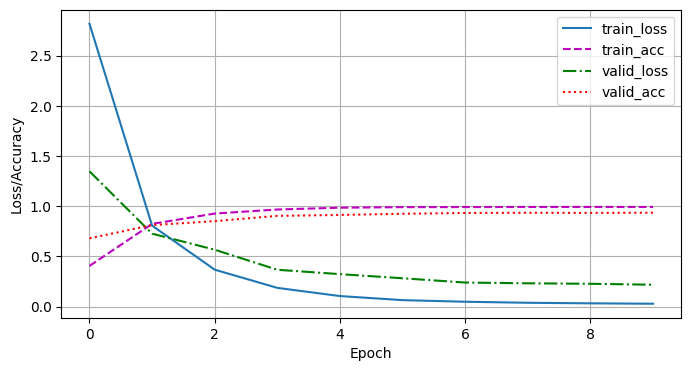

In [12]:
plt.rcParams['savefig.format'] = 'svg'
plt.figure(figsize=(8, 4))
plt.plot(train_losses, '-', label="train_loss")
plt.plot(train_accs, 'm--', label="train_acc")
plt.plot(valid_losses, 'g-.', label="valid_loss")
plt.plot(valid_accs, 'r:', label="valid_acc")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 重新定义模型
resnet = torchvision.models.resnet18()
resnet.fc = torch.nn.Linear(resnet.fc.in_features, num_classes)

# 加载训练好的权重
resnet.load_state_dict(torch.load(save_path, weights_only=True))

resnet.to(device)
resnet.eval()
print("模型已加载并设置为评估模式！")

模型已加载并设置为评估模式！


In [14]:
resnet.eval()

# 单张图片预测
img_test_path = os.path.join(base_dir, 'raw_images', test_df['image'][0].split('/')[-1])
image_test = Image.open(img_test_path)
image_test_tensor = transform(image_test).unsqueeze(0)

# 预测
with torch.no_grad():
    image_test_tensor = image_test_tensor.to(device)
    output = resnet(image_test_tensor)
    probabilities = F.softmax(output, dim=1)
    pred_class = torch.argmax(probabilities).item()

print(torch.max(probabilities).item()*100,'%')
print(idx_label[pred_class])

98.73375296592712 %
asimina_triloba


In [15]:
class LeaveTestDataset(Dataset):
    def __init__(self, data_df, transform=None):
        self.data = data_df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(base_dir,'raw_images', self.data.iloc[idx,0].split('/')[-1])
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)
        
        return image

test_dataset = LeaveTestDataset(test_df,transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print("test batch num:",len(test_loader))

test batch num: 69


In [16]:
all_preds = []

with torch.no_grad():
    for inputs in tqdm(test_loader):
        inputs = inputs.to(device)
        outputs = resnet(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())

print("批量预测结果长度:", len(all_preds))

100%|██████████| 69/69 [02:11<00:00,  1.91s/it]

批量预测结果长度: 8800


In [17]:
pred_labels = [idx_label[pred_id] for pred_id in all_preds] # 转换成label
test_df['label'] = pred_labels
test_df.to_csv('prediction.csv',index=False)